<a href="https://colab.research.google.com/github/jainMaurya/UCS547-Accelerated-Data-Science/blob/main/Assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Q1: RAPIDS cuML**

In [87]:
import pandas as pd

cols=[
    "age","workclass","fnlwgt","education",
    "education_num","marital_status","occupation",
    "relationship","race","sex","capital_gain",
    "capital_loss","hours_per_week",
    "native_country","income"
]

url="https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

df=pd.read_csv(
    url,
    names=cols,
    sep=", ",
    engine="python"
)

print(df.head())

   age         workclass  fnlwgt  education  education_num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital_status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital_gain  capital_loss  hours_per_week native_country income  
0          2174             0              40  United-States  <=50K  
1             0             0             

In [88]:
continuous=[
    "age",
    "fnlwgt",
    "capital_gain",
    "capital_loss",
    "hours_per_week"
]

categorical=[
    "workclass",
    "education",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "native_country"
]

binary=["sex","income"]

discrete=["education_num"]

print("Continuous:",continuous)

print("Categorical:",categorical)

print("Binary:",binary)

print("Discrete:",discrete)

Continuous: ['age', 'fnlwgt', 'capital_gain', 'capital_loss', 'hours_per_week']
Categorical: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']
Binary: ['sex', 'income']
Discrete: ['education_num']


In [89]:
import cudf
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt

gdf=cudf.from_pandas(df)

gpu_data=gdf["age"].values

gpu_hist,gpu_bins=cp.histogram(
    gpu_data,
    bins=10
)

cpu_hist,cpu_bins=np.histogram(
    df["age"],
    bins=10
)

print("GPU Histogram")

print(gpu_hist)

print("CPU Histogram")

print(cpu_hist)

GPU Histogram
[5570 5890 6048 6163 3967 2591 1595  496  174   67]
CPU Histogram
[5570 5890 6048 6163 3967 2591 1595  496  174   67]


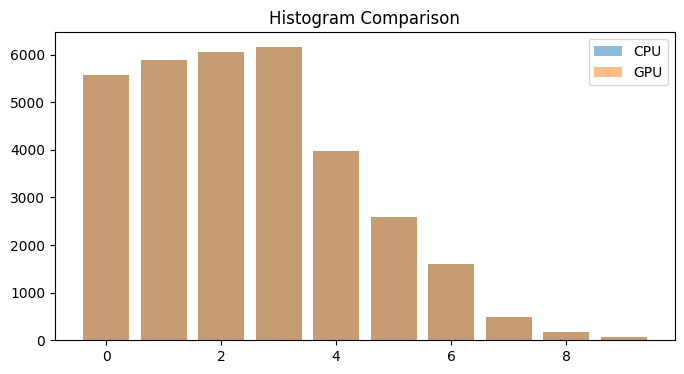

In [90]:
plt.figure(figsize=(8,4))

plt.bar(
    range(len(cpu_hist)),
    cpu_hist,
    alpha=0.5,
    label="CPU"
)

plt.bar(
    range(len(gpu_hist)),
    cp.asnumpy(gpu_hist),
    alpha=0.5,
    label="GPU"
)

plt.legend()

plt.title("Histogram Comparison")

plt.show()

In [91]:
import cupy as cp

gpu_age=cp.asarray(
    gdf["age"].to_numpy()
)

quantiles=cp.percentile(
    gpu_age,
    [25,50,75]
)

print("Quantiles")

print(quantiles)

bins=cp.asarray([
    gpu_age.min(),
    quantiles[0],
    quantiles[1],
    quantiles[2],
    gpu_age.max()
])

labels=cp.digitize(
    gpu_age,
    bins
)

gdf["age_bin"]=labels

print(
    gdf[["age","age_bin"]].head()
)

Quantiles
[28. 37. 48.]
   age  age_bin
0   39        3
1   50        4
2   38        3
3   53        4
4   28        2


In [92]:
from sklearn.preprocessing import LabelEncoder

for col in categorical+binary:

    enc=LabelEncoder()

    df[col]=enc.fit_transform(df[col])

X=df.drop("income",axis=1)

y=df["income"]

In [93]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [94]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time

start=time.time()

cpu_model=RandomForestClassifier(
    n_estimators=100
)

cpu_model.fit(X_train,y_train)

cpu_train=time.time()-start

start=time.time()

cpu_pred=cpu_model.predict(X_test)

cpu_pred_time=time.time()-start

cpu_acc=accuracy_score(
    y_test,
    cpu_pred
)

print(cpu_acc)

0.8621219100261016


In [95]:
import cudf

X_train_gpu=cudf.DataFrame(X_train)

X_test_gpu=cudf.DataFrame(X_test)

y_train_gpu=cudf.Series(y_train)

In [96]:
from cuml.ensemble import RandomForestClassifier as cuRF

X_train_gpu=cudf.from_pandas(X_train)

X_test_gpu=cudf.from_pandas(X_test)

y_train_gpu=cudf.from_pandas(
    y_train.to_frame()
)["income"]

start=time.time()

gpu_model=cuRF(
    n_estimators=100
)

gpu_model.fit(
    X_train_gpu,
    y_train_gpu
)

gpu_train=time.time()-start

start=time.time()

gpu_pred=gpu_model.predict(
    X_test_gpu
)

gpu_pred_time=time.time()-start

gpu_acc=accuracy_score(
    y_test,
    cp.asnumpy(gpu_pred)
)

print("GPU Accuracy:",gpu_acc)

GPU Accuracy: 0.8641179180101336


In [97]:
speedup=cpu_train/gpu_train

print("GPU Speedup:",speedup)

GPU Speedup: 7.2550014407383046


In [98]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import time

start=time.time()

xgb_model=XGBClassifier(
    tree_method="hist",
    device="cuda"
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_time=time.time()-start

xgb_pred=xgb_model.predict(
    X_test
)

xgb_acc=accuracy_score(
    y_test,
    xgb_pred
)

print("XGBoost Accuracy:",xgb_acc)

print("XGBoost Time:",xgb_time)

XGBoost Accuracy: 0.874251497005988
XGBoost Time: 0.19013571739196777


In [99]:
import pandas as pd

table=pd.DataFrame({
    "Model":[
        "CPU RF",
        "GPU cuML RF",
        "XGBoost GPU"
    ],
    "Train Time":[
        cpu_train,
        gpu_train,
        xgb_time
    ],
    "Accuracy":[
        cpu_acc,
        gpu_acc,
        xgb_acc
    ]
})

print(table)

         Model  Train Time  Accuracy
0       CPU RF    2.995457  0.862122
1  GPU cuML RF    0.412882  0.864118
2  XGBoost GPU    0.190136  0.874251


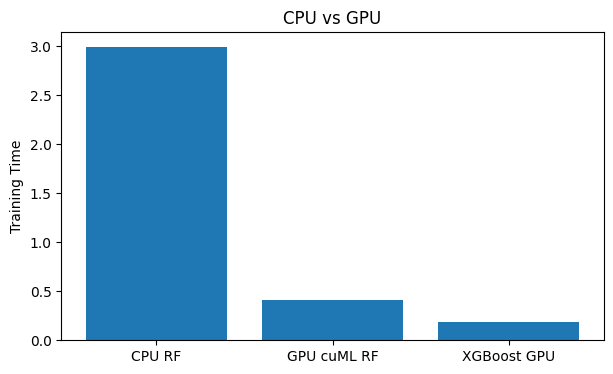

In [100]:
plt.figure(figsize=(7,4))

plt.bar(
    table["Model"],
    table["Train Time"]
)

plt.ylabel("Training Time")

plt.title("CPU vs GPU")

plt.show()

# **Q2: Breast Cancer Dataset**

In [101]:
from sklearn.datasets import load_breast_cancer

data=load_breast_cancer()

X=data.data

y=data.target

In [102]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [103]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time

start=time.time()

cpu_rf=RandomForestClassifier(
    n_estimators=100
)

cpu_rf.fit(
    X_train,
    y_train
)

cpu_train=time.time()-start

start=time.time()

cpu_pred=cpu_rf.predict(
    X_test
)

cpu_pred_time=time.time()-start

cpu_acc=accuracy_score(
    y_test,
    cpu_pred
)

print("CPU Accuracy:",cpu_acc)

CPU Accuracy: 0.9649122807017544


In [104]:
import cudf

X_train_gpu=cudf.DataFrame(X_train)

X_test_gpu=cudf.DataFrame(X_test)

y_train_gpu=cudf.Series(y_train)

In [105]:
from cuml.ensemble import RandomForestClassifier as cuRF

start=time.time()

gpu_rf=cuRF(
    n_estimators=100
)

gpu_rf.fit(
    X_train_gpu,
    y_train_gpu
)

gpu_train=time.time()-start

start=time.time()

gpu_pred=gpu_rf.predict(X_test_gpu)

gpu_pred_time=time.time()-start

gpu_acc=accuracy_score(
    y_test,
    cp.asnumpy(gpu_pred)
)

print(gpu_acc)

0.9649122807017544


In [106]:
speedup=cpu_train/gpu_train

print("GPU Speedup:",speedup)

GPU Speedup: 1.5778439536112299


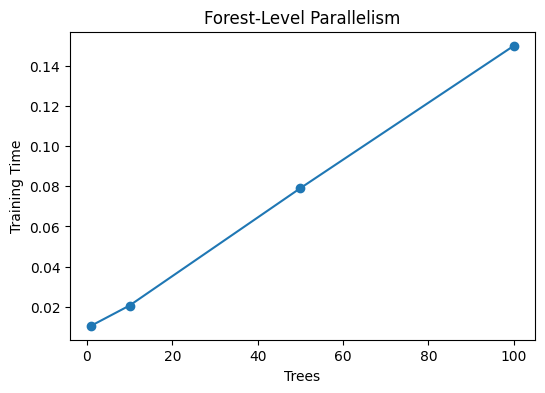

In [107]:
trees=[1,10,50,100]

times=[]

for n in trees:

    start=time.time()

    model=cuRF(
        n_estimators=n
    )

    model.fit(
        X_train_gpu,
        y_train_gpu
    )

    t=time.time()-start

    times.append(t)

plt.figure(figsize=(6,4))

plt.plot(
    trees,
    times,
    marker='o'
)

plt.xlabel("Trees")

plt.ylabel("Training Time")

plt.title("Forest-Level Parallelism")

plt.show()

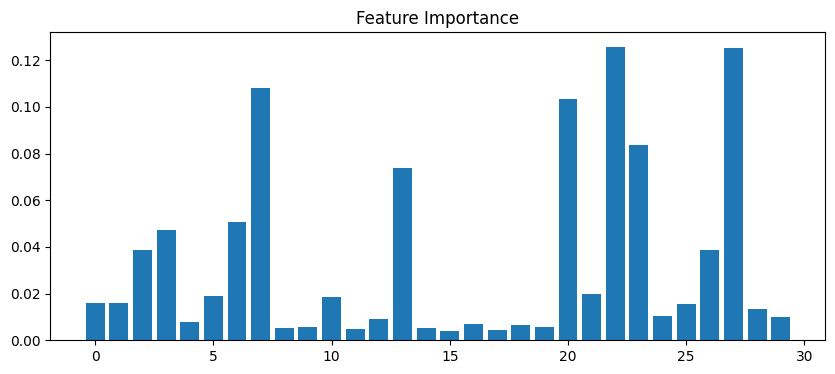

In [108]:
importance=cpu_rf.feature_importances_

plt.figure(figsize=(10,4))

plt.bar(
    range(len(importance)),
    importance
)

plt.title("Feature Importance")

plt.show()

/usr/local/lib/python3.12/dist-packages/cuml/ensemble/randomforestclassifier.py:247: UserWarning: The number of bins, `n_bins` is greater than the number of samples used for training. Changing `n_bins` to number of training samples.
  return self._fit_forest(X_m, y_m)


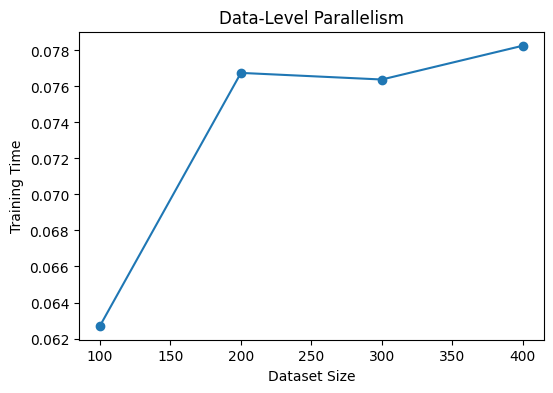

In [109]:
sizes=[100,200,300,400]

data_times=[]

for s in sizes:

    start=time.time()

    model=cuRF(
        n_estimators=50
    )

    model.fit(
        X_train_gpu.iloc[:s],
        y_train_gpu.iloc[:s]
    )

    t=time.time()-start

    data_times.append(t)

plt.figure(figsize=(6,4))

plt.plot(
    sizes,
    data_times,
    marker='o'
)

plt.xlabel("Dataset Size")

plt.ylabel("Training Time")

plt.title("Data-Level Parallelism")

plt.show()

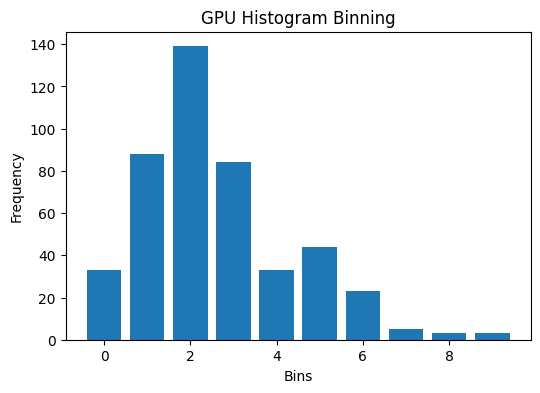

In [110]:
gpu_hist,gpu_bins=cp.histogram(
    cp.asarray(X_train[:,0]),
    bins=10
)

plt.figure(figsize=(6,4))

plt.bar(
    range(len(gpu_hist)),
    cp.asnumpy(gpu_hist)
)

plt.xlabel("Bins")

plt.ylabel("Frequency")

plt.title("GPU Histogram Binning")

plt.show()

In [111]:
final_table=pd.DataFrame({
    "Model":["CPU RF","GPU RF"],
    "Train Time":[cpu_train,gpu_train],
    "Prediction Time":[cpu_pred_time,gpu_pred_time],
    "Accuracy":[cpu_acc,gpu_acc]
})

print(final_table)

    Model  Train Time  Prediction Time  Accuracy
0  CPU RF    0.239261         0.011163  0.964912
1  GPU RF    0.151638         0.004119  0.964912


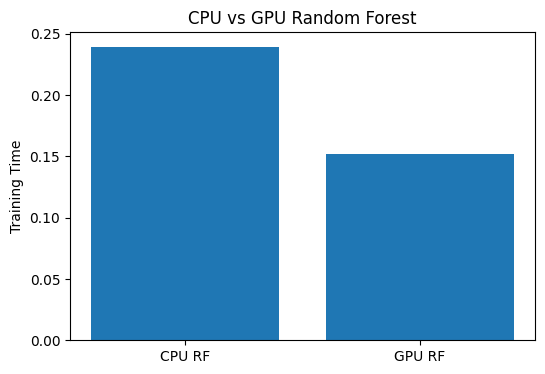

In [112]:
plt.figure(figsize=(6,4))

plt.bar(
    final_table["Model"],
    final_table["Train Time"]
)

plt.ylabel("Training Time")

plt.title("CPU vs GPU Random Forest")

plt.show()